<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Why Training Fails: Noise and Reproducibility

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `3.3`.


## Common setup

The next cell contains only the base imports and low-level linear-algebra helpers reused by the solutions below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We compare global and local observables in the same finite-size gradient-concentration experiment, so that the role of cost locality becomes visible under identical random initializations.


global medians: {2: 1.309307889484943, 4: 0.7734396395240694, 6: 0.40851796412503105}
local medians: {2: 1.121316218931934, 4: 1.0662377048637866, 6: 0.8553764156890091}


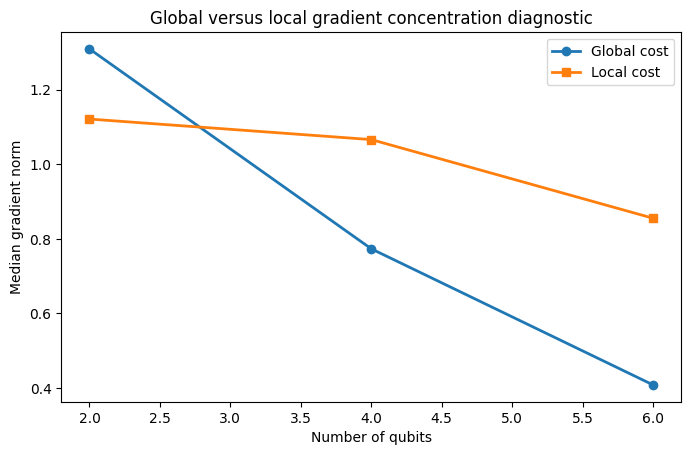

In [2]:
def make_hardware_efficient_qnode(n_qubits, observable="global"):
    device = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(device)
    def circuit(weights, depth):
        idx = 0
        for _ in range(depth):
            for q in range(n_qubits):
                qml.RY(float(weights[idx]), wires=q)
                idx += 1
                qml.RZ(float(weights[idx]), wires=q)
                idx += 1
            for q in range(n_qubits - 1):
                qml.CZ(wires=[q, q + 1])
        if observable == "global":
            measured = qml.PauliZ(0)
            for q in range(1, n_qubits):
                measured = measured @ qml.PauliZ(q)
        elif observable == "local":
            measured = qml.PauliZ(0)
        else:
            raise ValueError("observable must be 'global' or 'local'")
        return qml.expval(measured)

    return circuit


HARDWARE_EFFICIENT_QNODES = {}


def generic_cost(weights, n_qubits, depth, observable="global"):
    key = (n_qubits, observable)
    if key not in HARDWARE_EFFICIENT_QNODES:
        HARDWARE_EFFICIENT_QNODES[key] = make_hardware_efficient_qnode(n_qubits, observable)
    qnode = HARDWARE_EFFICIENT_QNODES[key]
    return float(qnode(weights, depth))


def parameter_shift_gradient_generic(weights, n_qubits, depth, observable="global"):
    gradient = np.zeros_like(weights, dtype=float)
    shift = np.pi / 2.0
    for m in range(len(weights)):
        weights_plus = weights.copy()
        weights_minus = weights.copy()
        weights_plus[m] += shift
        weights_minus[m] -= shift
        gradient[m] = 0.5 * (
            generic_cost(weights_plus, n_qubits, depth, observable)
            - generic_cost(weights_minus, n_qubits, depth, observable)
        )
    return gradient


def gradient_norm(vector):
    return float(np.linalg.norm(vector))


def sample_random_weights(qubit_counts, depth, n_repeats, seed):
    rng = np.random.default_rng(seed)
    samples = {}
    for n_qubits in qubit_counts:
        param_count = 2 * n_qubits * depth
        samples[n_qubits] = [
            rng.uniform(-np.pi, np.pi, size=param_count) for _ in range(n_repeats)
        ]
    return samples


def gradient_concentration_from_samples(weight_samples, depth, observable="global"):
    rows = []
    for n_qubits in sorted(weight_samples):
        norms = []
        for weights in weight_samples[n_qubits]:
            grad = parameter_shift_gradient_generic(weights, n_qubits, depth, observable)
            norms.append(gradient_norm(grad))
        rows.append(
            {
                "n_qubits": n_qubits,
                "norms": norms,
                "median_norm": float(np.median(norms)),
                "mean_norm": float(np.mean(norms)),
            }
        )
    return rows


qubit_counts_bp = [2, 4, 6]
depth_bp = 4
repeats_bp = 8
seed_bp = 7

weight_samples_bp = sample_random_weights(qubit_counts_bp, depth_bp, repeats_bp, seed_bp)
stats_global = gradient_concentration_from_samples(weight_samples_bp, depth_bp, observable="global")
stats_local = gradient_concentration_from_samples(weight_samples_bp, depth_bp, observable="local")

global_medians = {row["n_qubits"]: row["median_norm"] for row in stats_global}
local_medians = {row["n_qubits"]: row["median_norm"] for row in stats_local}

print("global medians:", global_medians)
print("local medians:", local_medians)

fig, ax = plt.subplots(figsize=(8.0, 4.8))
qubit_positions = qubit_counts_bp
ax.plot(
    qubit_positions,
    [global_medians[n] for n in qubit_positions],
    marker="o",
    linewidth=2.0,
    label="Global cost",
)
ax.plot(
    qubit_positions,
    [local_medians[n] for n in qubit_positions],
    marker="s",
    linewidth=2.0,
    label="Local cost",
)
ax.set_xlabel("Number of qubits")
ax.set_ylabel("Median gradient norm")
ax.set_title("Global versus local gradient concentration diagnostic")
ax.legend()
plt.show()


On the same random initializations, the global cost typically shows a much steeper decline in median gradient norm as the number of qubits grows, while the local cost remains noticeably larger. That is exactly the finite-size pattern one expects when local observables retain more trainability than highly global ones. What makes this undesirable is not that gradients are always supposed to stay large, but that the global ones can become very small already at random initialization or very early in training, when the optimizer still needs a clear update signal.

The reason is structural rather than mysterious. A local observable such as $Z_0$ probes only a restricted part of the circuit output, whereas the fully global observable $Z_0 \otimes \cdots \otimes Z_{n-1}$ depends on correlations across the whole register. In random expressive circuits, those global correlations tend to concentrate more quickly, so their gradients become small sooner. Near a well-optimized minimum, small gradients can be completely normal; the warning sign is when they become small too early and across too broad a region of parameter space.


<a id="task2-solution"></a>

## Task 2 (coding): One complete solution

We compare shot-based gradient reproducibility for two parameter vectors: one with stronger exact gradients and one closer to a near-stationary region.



reference exact gradient: [-0.3858  0.2304 -0.688   0.1457 -0.7163 -0.    ]
shots=32: mean norm error = 1.1324, max flip rate = 0.42
shots=64: mean norm error = 0.6929, max flip rate = 0.47
shots=128: mean norm error = 0.4356, max flip rate = 0.53
shots=256: mean norm error = 0.3534, max flip rate = 0.60

near_stationary exact gradient: [-0.0117 -0.0886 -0.0433  0.0432  0.0139  0.    ]
shots=32: mean norm error = 0.7707, max flip rate = 0.53
shots=64: mean norm error = 0.4188, max flip rate = 0.50
shots=128: mean norm error = 0.2486, max flip rate = 0.35
shots=256: mean norm error = 0.1253, max flip rate = 0.42


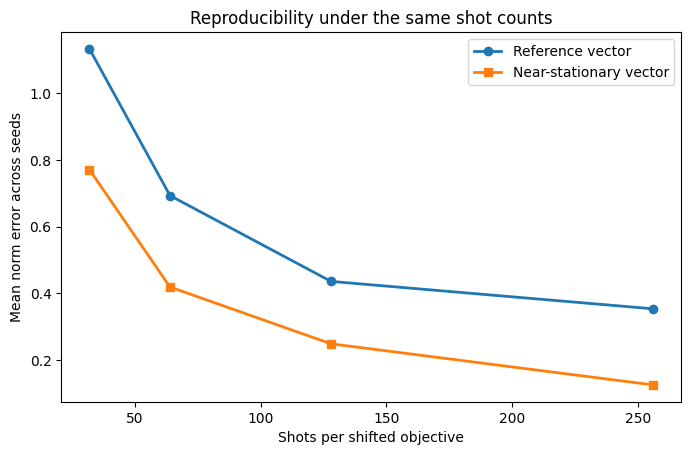

In [3]:
def one_qubit_reupload_template(x, weights):
    n_layers = len(weights) // 2
    for layer in range(n_layers):
        qml.RY(float(x[0]), wires=0)
        qml.RZ(float(x[1]), wires=0)
        qml.RY(float(weights[2 * layer]), wires=0)
        qml.RZ(float(weights[2 * layer + 1]), wires=0)


ANALYTIC_ONE_QUBIT_DEVICE = qml.device("default.qubit", wires=1)


@qml.qnode(ANALYTIC_ONE_QUBIT_DEVICE)
def analytic_score_one_qubit_qnode(x, weights):
    one_qubit_reupload_template(x, weights)
    return qml.expval(qml.PauliZ(0))


def scalar_score_one_qubit(x, weights):
    return float(analytic_score_one_qubit_qnode(x, weights))


def score_to_probability(score, eps=1e-9):
    probability = 0.5 * (1.0 + score)
    return float(np.clip(probability, eps, 1.0 - eps))


def bce_per_sample(y_true, probability):
    return float(-y_true * np.log(probability) - (1.0 - y_true) * np.log(1.0 - probability))


def exact_bce_dataset(samples, labels, weights):
    probabilities = [score_to_probability(scalar_score_one_qubit(x, weights)) for x in samples]
    return float(np.mean([bce_per_sample(y, p) for y, p in zip(labels, probabilities)]))


SHOT_QNODE_CACHE = {}


def get_shot_score_one_qubit_qnode(seed, shots):
    key = (int(seed), int(shots))
    if key not in SHOT_QNODE_CACHE:
        shot_device = qml.device("default.qubit", wires=1, seed=int(seed))

        @qml.qnode(shot_device)
        def shot_score_one_qubit_qnode(x, weights):
            one_qubit_reupload_template(x, weights)
            return qml.expval(qml.PauliZ(0))

        SHOT_QNODE_CACHE[key] = qml.set_shots(shot_score_one_qubit_qnode, shots=int(shots))
    return SHOT_QNODE_CACHE[key]


def shot_based_score(x, weights, shots, seed):
    shot_qnode = get_shot_score_one_qubit_qnode(seed, shots)
    return float(shot_qnode(x, weights))


def shot_based_bce_dataset(samples, labels, weights, shots, seed):
    rng = np.random.default_rng(seed)
    losses = []
    for x, y in zip(samples, labels):
        local_seed = int(rng.integers(0, 1_000_000_000))
        score_hat = shot_based_score(x, weights, shots, local_seed)
        probability_hat = score_to_probability(score_hat)
        losses.append(bce_per_sample(y, probability_hat))
    return float(np.mean(losses))


def parameter_shift_bce_gradient_exact(samples, labels, weights):
    gradient = np.zeros_like(weights, dtype=float)
    shift = np.pi / 2.0
    for m in range(len(weights)):
        weights_plus = weights.copy()
        weights_minus = weights.copy()
        weights_plus[m] += shift
        weights_minus[m] -= shift
        gradient[m] = 0.5 * (
            exact_bce_dataset(samples, labels, weights_plus)
            - exact_bce_dataset(samples, labels, weights_minus)
        )
    return gradient


def parameter_shift_bce_gradient_shot(samples, labels, weights, shots, seed):
    gradient = np.zeros_like(weights, dtype=float)
    shift = np.pi / 2.0
    rng = np.random.default_rng(seed)
    for m in range(len(weights)):
        weights_plus = weights.copy()
        weights_minus = weights.copy()
        weights_plus[m] += shift
        weights_minus[m] -= shift
        seed_plus = int(rng.integers(0, 1_000_000_000))
        seed_minus = int(rng.integers(0, 1_000_000_000))
        gradient[m] = 0.5 * (
            shot_based_bce_dataset(samples, labels, weights_plus, shots, seed_plus)
            - shot_based_bce_dataset(samples, labels, weights_minus, shots, seed_minus)
        )
    return gradient


def gradient_reproducibility_statistics(samples, labels, weights, shot_values, repeat_seeds):
    reference_gradient = parameter_shift_bce_gradient_exact(samples, labels, weights)
    rows = []
    flip_rates = []
    for shots in shot_values:
        estimates = np.array(
            [
                parameter_shift_bce_gradient_shot(samples, labels, weights, shots, seed)
                for seed in repeat_seeds
            ]
        )
        errors = np.linalg.norm(estimates - reference_gradient, axis=1)
        flip = np.mean(np.sign(estimates) != np.sign(reference_gradient), axis=0)
        flip_rates.append(flip)
        rows.append(
            {
                "shots": shots,
                "mean_norm_error": float(np.mean(errors)),
                "std_norm_error": float(np.std(errors)),
                "component_std": np.std(estimates, axis=0),
                "flip_rate": flip,
                "estimates": estimates,
            }
        )
    return {
        "reference_gradient": reference_gradient,
        "rows": rows,
        "flip_rate_matrix": np.array(flip_rates),
    }


samples_shot, labels_shot = make_moons(n_samples=24, noise=0.18, random_state=4)
samples_shot = (samples_shot - samples_shot.mean(axis=0)) / samples_shot.std(axis=0)
labels_shot = labels_shot.astype(float)

shot_values = [32, 64, 128, 256]
repeat_seeds = list(range(40))
weights_ref = np.array([0.35, -0.40, 0.25, 0.15, -0.20, 0.30])
weights_flat = np.array([-1.553, -0.169, -1.315, 0.335, -2.024, 1.748])

study_ref = gradient_reproducibility_statistics(samples_shot, labels_shot, weights_ref, shot_values, repeat_seeds)
study_flat = gradient_reproducibility_statistics(samples_shot, labels_shot, weights_flat, shot_values, repeat_seeds)

studies = {
    "reference": study_ref,
    "near_stationary": study_flat,
}

for name, study in studies.items():
    print(f"\n{name} exact gradient:", np.round(study["reference_gradient"], 4))
    for row in study["rows"]:
        print(
            f"shots={row['shots']}: mean norm error = {row['mean_norm_error']:.4f}, "
            f"max flip rate = {row['flip_rate'].max():.2f}"
        )

fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.plot(
    shot_values,
    [row["mean_norm_error"] for row in study_ref["rows"]],
    marker="o",
    linewidth=2.0,
    label="Reference vector",
)
ax.plot(
    shot_values,
    [row["mean_norm_error"] for row in study_flat["rows"]],
    marker="s",
    linewidth=2.0,
    label="Near-stationary vector",
)
ax.set_xlabel("Shots per shifted objective")
ax.set_ylabel("Mean norm error across seeds")
ax.set_title("Reproducibility under the same shot counts")
ax.legend()
plt.show()


The near-stationary vector is the less reproducible one under the same shot counts. Its exact gradient components are already small, so the shot-based perturbations have a larger relative effect on the direction inferred by the optimizer. In contrast, the reference vector contains stronger components, which makes the same amount of sampling noise less destructive.

That is the key point of the exercise: reproducibility is not determined by shot count alone. It depends on the ratio between estimator noise and the underlying gradient scale. A shot budget that is adequate in one region of parameter space may be inadequate near a flatter region.


<a id="task3-solution"></a>

## Task 3 (coding): One complete solution

We compare two circuit depths under repeated seeds, then summarize which depth is more stable with respect to validation loss, stopping epoch, and test accuracy. The helper functions below reuse the one-qubit score and BCE utilities defined in Task 2.


{'depth': 3, 'mean_best_val': 0.6628732869017322, 'std_best_val': 0.07473454366984982, 'mean_test_acc': 0.7015873015873015, 'std_test_acc': 0.049436226991737886, 'median_best_epoch': 5.0}
{'depth': 5, 'mean_best_val': 0.9115097138357416, 'std_best_val': 0.17791030410235992, 'mean_test_acc': 0.6063492063492063, 'std_test_acc': 0.0941739490424846, 'median_best_epoch': 68.0}


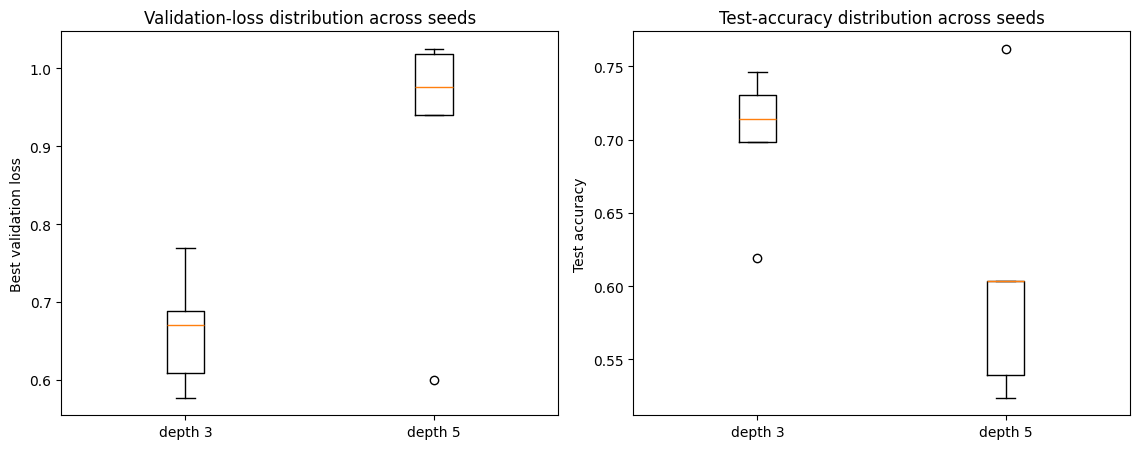

In [4]:
def prepare_small_noisy_dataset(data_seed=11, split_seed=23, n_train=14, n_val=50, flipped_labels=4):
    X_data, y_data = make_moons(n_samples=180, noise=0.28, random_state=data_seed)
    X_data = (X_data - X_data.mean(axis=0)) / X_data.std(axis=0)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_data,
        y_data,
        test_size=0.35,
        random_state=split_seed,
        stratify=y_data,
    )
    X_train_big, X_val, y_train_big, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=n_val,
        random_state=split_seed + 1,
        stratify=y_temp,
    )
    rng = np.random.default_rng(split_seed)
    idx0 = np.where(y_train_big == 0)[0]
    idx1 = np.where(y_train_big == 1)[0]
    sel0 = rng.choice(idx0, size=n_train // 2, replace=False)
    sel1 = rng.choice(idx1, size=n_train - n_train // 2, replace=False)
    selection = np.concatenate([sel0, sel1])
    X_train = X_train_big[selection]
    y_train = y_train_big[selection].astype(float)
    flipped_idx = rng.choice(len(y_train), size=flipped_labels, replace=False)
    y_train_noisy = y_train.copy()
    y_train_noisy[flipped_idx] = 1.0 - y_train_noisy[flipped_idx]
    return (
        X_train,
        y_train_noisy,
        X_val,
        y_val.astype(float),
        X_test,
        y_test.astype(float),
        flipped_idx,
    )


def dataset_accuracy(samples, labels, weights):
    probabilities = np.array([score_to_probability(scalar_score_one_qubit(x, weights)) for x in samples])
    predictions = (probabilities >= 0.5).astype(float)
    return float(np.mean(predictions == labels))


def train_one_qubit_adam(samples_train, labels_train, samples_val, labels_val, weights0, lr=0.07, epochs=100):
    weights = weights0.copy().astype(float)
    first_moment = np.zeros_like(weights)
    second_moment = np.zeros_like(weights)
    beta1, beta2 = 0.9, 0.999
    history = {"train_loss": [], "val_loss": []}
    best_weights = weights.copy()
    best_val_loss = float("inf")
    best_epoch = 0
    for t in range(1, epochs + 1):
        gradient = parameter_shift_bce_gradient_exact(samples_train, labels_train, weights)
        first_moment = beta1 * first_moment + (1.0 - beta1) * gradient
        second_moment = beta2 * second_moment + (1.0 - beta2) * (gradient ** 2)
        m_hat = first_moment / (1.0 - beta1 ** t)
        v_hat = second_moment / (1.0 - beta2 ** t)
        weights = weights - lr * m_hat / (np.sqrt(v_hat) + 1e-8)
        train_loss = exact_bce_dataset(samples_train, labels_train, weights)
        val_loss = exact_bce_dataset(samples_val, labels_val, weights)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = weights.copy()
            best_epoch = t
    return {
        "final_weights": weights,
        "best_weights": best_weights,
        "history": history,
        "best_epoch": best_epoch,
    }


def repeated_seed_study(
    run_seeds,
    depth,
    data_seed=11,
    split_seed=23,
    n_train=14,
    n_val=50,
    flipped_labels=4,
    lr=0.07,
    epochs=100,
):
    (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        flipped_idx,
    ) = prepare_small_noisy_dataset(
        data_seed=data_seed,
        split_seed=split_seed,
        n_train=n_train,
        n_val=n_val,
        flipped_labels=flipped_labels,
    )
    rows = []
    histories = {}
    for seed in run_seeds:
        rng = np.random.default_rng(seed)
        weights0 = rng.normal(scale=0.4, size=2 * depth)
        result = train_one_qubit_adam(X_train, y_train, X_val, y_val, weights0, lr=lr, epochs=epochs)
        best_weights = result["best_weights"]
        row = {
            "seed": seed,
            "best_epoch": result["best_epoch"],
            "best_val_loss": float(np.min(result["history"]["val_loss"])),
            "test_accuracy": dataset_accuracy(X_test, y_test, best_weights),
        }
        rows.append(row)
        histories[seed] = result["history"]
    return {
        "rows": rows,
        "histories": histories,
        "flipped_idx": flipped_idx,
        "dataset": (X_train, y_train, X_val, y_val, X_test, y_test),
    }


depths_repro = [3, 5]
run_seeds_repro = [2, 7, 19, 31, 43]

depth_studies = {
    depth: repeated_seed_study(run_seeds_repro, depth=depth, epochs=100)
    for depth in depths_repro
}

summary_rows = []
for depth, study in depth_studies.items():
    best_val = np.array([row["best_val_loss"] for row in study["rows"]])
    test_acc = np.array([row["test_accuracy"] for row in study["rows"]])
    best_epoch = np.array([row["best_epoch"] for row in study["rows"]])
    summary_rows.append(
        {
            "depth": depth,
            "mean_best_val": float(best_val.mean()),
            "std_best_val": float(best_val.std(ddof=1)),
            "mean_test_acc": float(test_acc.mean()),
            "std_test_acc": float(test_acc.std(ddof=1)),
            "median_best_epoch": float(np.median(best_epoch)),
        }
    )

for row in summary_rows:
    print(row)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].boxplot(
    [[row["best_val_loss"] for row in depth_studies[depth]["rows"]] for depth in depths_repro],
    tick_labels=[f"depth {depth}" for depth in depths_repro],
)
axes[0].set_ylabel("Best validation loss")
axes[0].set_title("Validation-loss distribution across seeds")

axes[1].boxplot(
    [[row["test_accuracy"] for row in depth_studies[depth]["rows"]] for depth in depths_repro],
    tick_labels=[f"depth {depth}" for depth in depths_repro],
)
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Test-accuracy distribution across seeds")

plt.tight_layout()
plt.show()


In this study, depth `3` is the more stable configuration. Its best validation losses vary less across seeds, its average test accuracy is higher, and its preferred stopping epoch remains relatively early. Depth `5`, by contrast, is much more seed-sensitive: one run finds a much better validation checkpoint, while the others remain clearly worse, and the median best epoch shifts later.

That pattern is consistent with stronger overfitting pressure in the deeper model. The expressive circuit can drive the tiny noisy training set to very low loss, but that extra flexibility does not translate into stable validation or test performance. The right conclusion is not that depth `5` is useless, but that in this small-data regime it needs stronger controls and should not be judged from one lucky run.
